Complete the exercises below For **Assignment #11**.

For this assignment we'll use the [California Housing Data](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html).

This data is available in the [Scikit-Learn](https://scikit-learn.org/stable/index.html) Python module.

To retrieve the data,
1. open a new Python notebook with the `data730` kernel, and,
2. run the following code.

```python
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame=True)

(
    california_housing.data
    .assign(MedianHouseValue=california_housing.target)
    .to_csv('california-housing.csv', index=False)
)
```

This will produce a new file called `california-housing.csv` that we'll import in this notebook.

Back in the Python notebook, you can use the following snippet to get a description of the dataset.

```python
print(california_housing.DESCR)
```


Load the `tidymodels` package.

In [1]:
library('tidymodels')
library('dplyr')
library('vip')

── Attaching packages ────────────────────────────────────────────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.9     ✔ recipes      1.3.1
✔ dials        1.4.2     ✔ rsample      1.3.1
✔ dplyr        1.1.4     ✔ tailor       0.1.0
✔ ggplot2      3.5.2     ✔ tidyr        1.3.1
✔ infer        1.0.9     ✔ tune         2.0.0
✔ modeldata    1.5.1     ✔ workflows    1.3.0
✔ parsnip      1.3.3     ✔ workflowsets 1.1.1
✔ purrr        1.1.0     ✔ yardstick    1.3.2

── Conflicts ───────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()


Attaching package: 'vip'


The following object is masked from 'package:utils':

    vi




Run the following cell to read in our data.

In [2]:
housing = readr::read_csv('./california-housing.csv', col_types = readr::cols()) |> drop_na()

housing |> head()
housing |> glimpse()

MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8.3252,41,6.984127,1.0238095,322,2.555556,37.88,-122.23,4.526
8.3014,21,6.238137,0.9718805,2401,2.109842,37.86,-122.22,3.585
7.2574,52,8.288136,1.0734463,496,2.802260,37.85,-122.24,3.521
5.6431,52,5.817352,1.0730594,558,2.547945,37.85,-122.25,3.413
3.8462,52,6.281853,1.0810811,565,2.181467,37.85,-122.25,3.422
4.0368,52,4.761658,1.1036269,413,2.139896,37.85,-122.25,2.697


Rows: 20,640
Columns: 9
$ MedInc           <dbl> 8.3252, 8.3014, 7.2574, 5.6431, 3.8462, 4.0368, 3.659…
$ HouseAge         <dbl> 41, 21, 52, 52, 52, 52, 52, 52, 42, 52, 52, 52, 52, 5…
$ AveRooms         <dbl> 6.984127, 6.238137, 8.288136, 5.817352, 6.281853, 4.7…
$ AveBedrms        <dbl> 1.0238095, 0.9718805, 1.0734463, 1.0730594, 1.0810811…
$ Population       <dbl> 322, 2401, 496, 558, 565, 413, 1094, 1157, 1206, 1551…
$ AveOccup         <dbl> 2.555556, 2.109842, 2.802260, 2.547945, 2.181467, 2.1…
$ Latitude         <dbl> 37.88, 37.86, 37.85, 37.85, 37.85, 37.85, 37.84, 37.8…
$ Longitude        <dbl> -122.23, -122.22, -122.24, -122.25, -122.25, -122.25,…
$ MedianHouseValue <dbl> 4.526, 3.585, 3.521, 3.413, 3.422, 2.697, 2.992, 2.41…


Let's build a random forest model to predict `MedianHouseValue`.

1. Create your model, set the engine to `ranger` with `importance = 'impurity'` and the mode as `regression`.
2. Fit the model using `MedianHouseValue` as the response variable and all other columns as predictors.

In [3]:
housing |>
  summarize(
      median = median(MedianHouseValue),
      mean = mean(MedianHouseValue),
      max = max(MedianHouseValue),
      min = min(MedianHouseValue),
      std = sd(MedianHouseValue)
    )

median,mean,max,min,std
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.797,2.068558,5.00001,0.14999,1.153956


In [4]:
show_engines('rand_forest')

engine,mode
<chr>,<chr>
ranger,classification
ranger,regression
randomForest,classification
randomForest,regression
spark,classification
spark,regression


In [5]:
# None of these columns look like we need to alter them so I don't think we need a recipe here
mod = rand_forest(trees = 1000) |>
    set_engine('ranger', importance = 'impurity') |>
    set_mode('regression')

mod_fit = mod |> fit(MedianHouseValue ~ ., data = housing)

In [6]:
mod_fit

parsnip model object

Ranger result

Call:
 ranger::ranger(x = maybe_data_frame(x), y = y, num.trees = ~1000,      importance = ~"impurity", num.threads = 1, verbose = FALSE,      seed = sample.int(10^5, 1)) 

Type:                             Regression 
Number of trees:                  1000 
Sample size:                      20640 
Number of independent variables:  8 
Mtry:                             2 
Target node size:                 5 
Variable importance mode:         impurity 
Splitrule:                        variance 
OOB prediction error (MSE):       0.2332488 
R squared (OOB):                  0.8248377 

❓ What is the OOB error for this model?

**Answer:**

The out of bag error for this model is 0.2312142. Since this is MSE, I think we can take the square root of that value and find out that the prediction is off by about 0.48062. Since ```MedianHouseValue``` appears to be in \\$100,000 units, this model tends to be off by about \\$48,000. 

Plot the feature importances using the `vip` package. Remember that you can use the `extract_fit_engine` function to get the `ranger` model object to send to the `vip` function.

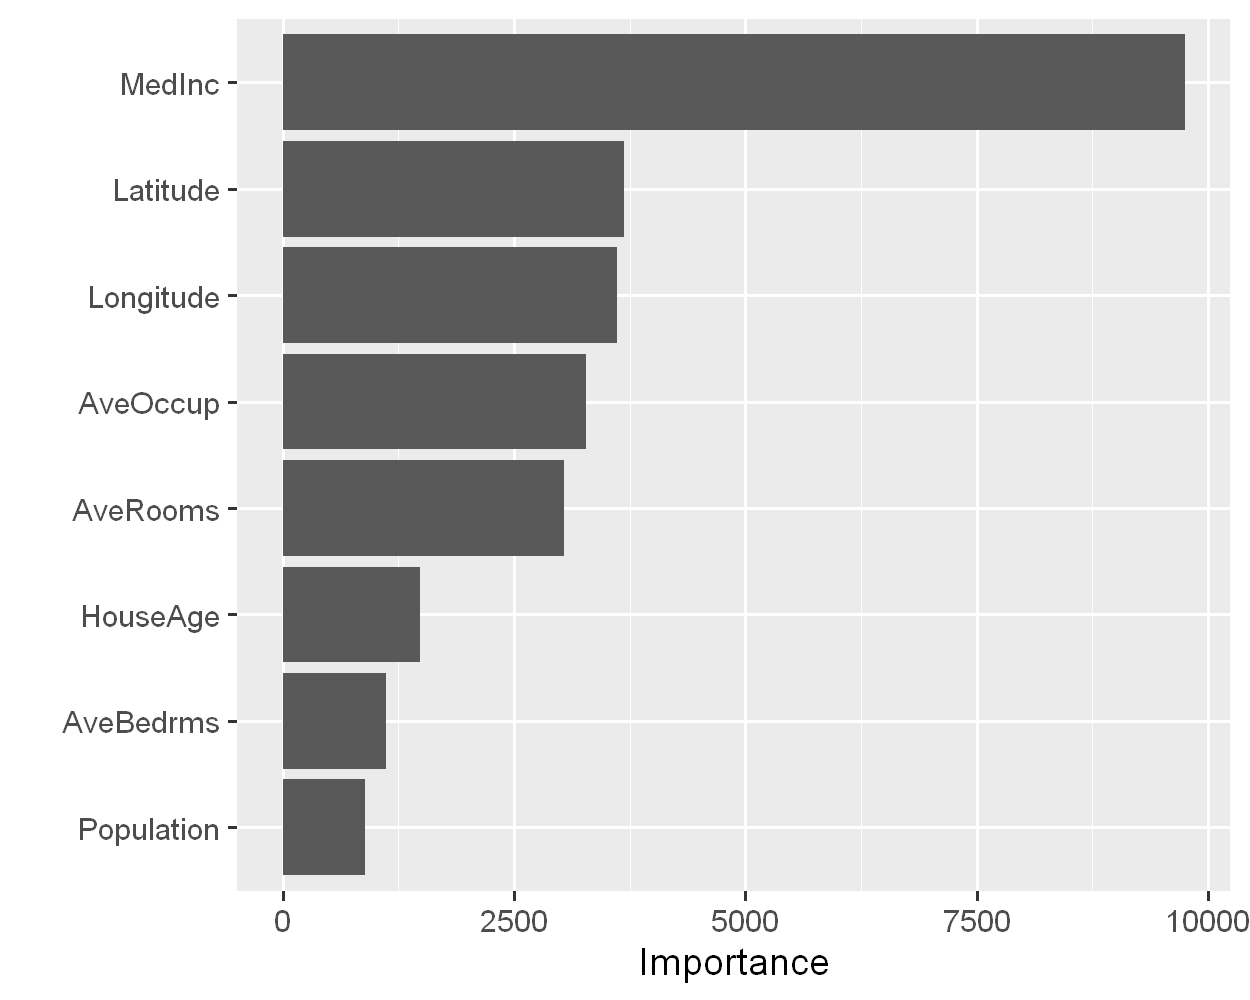

In [7]:
mod_fit |> extract_fit_engine() |> vip()

It looks like `Latitude` and `Longitude` are important for predicting home value. Let's explore those variables.

Install the `mapdata` package into your `data730` environment.

1. Open a Terminal, and,
2. Run the following command:

```bash
conda install -c conda-forge -n data730 r-mapdata
```

Load the `mapdata` package.

In [8]:
library('mapdata')

Loading required package: maps


Attaching package: 'maps'


The following object is masked from 'package:purrr':

    map




The following code will generate a map of California. Adapt this code to plot `Latitude` and `Longitude` from the `housing` dataset, color points by the `MedianHouseValue`. [Here is an example for reference](https://raw.githubusercontent.com/UNC-DATA-730/a10/main/example.png).


```r
california = map_data("state") |> filter(region == 'california')

ggplot(data = california) + 
    geom_polygon(aes(x = long, y = lat), fill = "grey90", color = "grey40") +
    coord_quickmap() +
    theme_void()
```

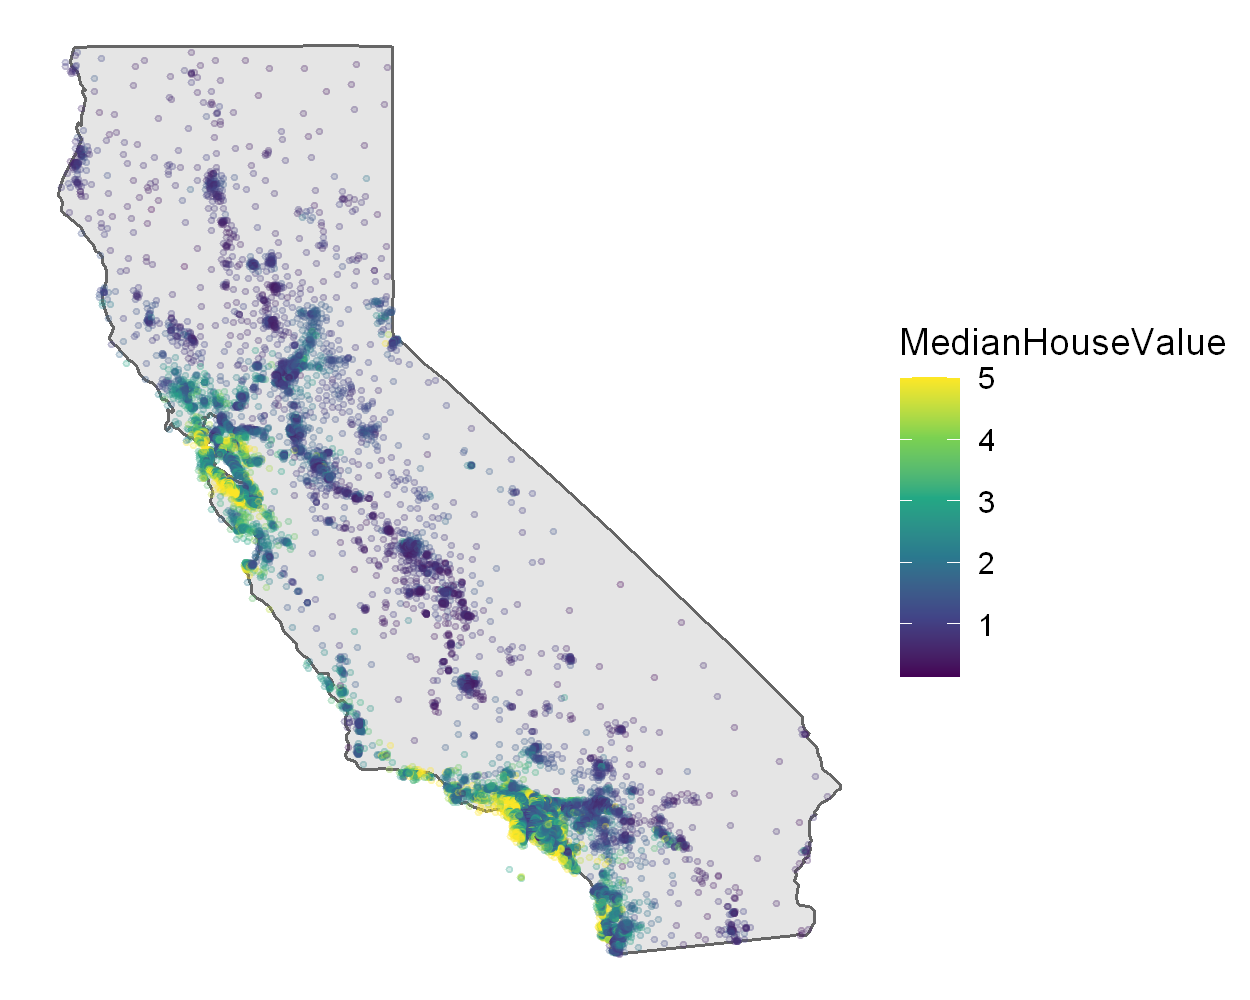

In [9]:
california = map_data("state") |> filter(region == 'california')

ggplot(data = california) + 
    geom_polygon(aes(x = long, y = lat), fill = "grey90", color = "grey40") +
    coord_quickmap() +
    theme_void() +
    geom_point(data = housing, aes(x = Longitude, y = Latitude, color = MedianHouseValue), alpha = 0.2, size = 0.6) +
    scale_color_viridis_c()